In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df_cust_raw = pd.read_csv('E:\Portfolio\K-Means clustering\CUSTOMERS_CLEAN.csv')


In [3]:
df_cust_raw.head()
df_cust_raw.shape


(951669, 20)

In [4]:
df_cust_raw.head(5)

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,$28.50,$9.10,.,Internet Sale,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,$1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$113.40,$56.90,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,($0.40),3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,$41.00,$18.50,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,$4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,$35.20,$29.60,.,Internet Sale,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,$5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,$24.70,$23.60,.,Internet Sale,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,$1.10,3,99,74503


**Cleaning the data**
- Removing Duplicates
- Cleaning the data from special char
- removing the currency sign from the column values
- finding the blank, null and NA values
- filling the blank, null and NA values with mean

In [5]:
df_cust_raw1 = df_cust_raw.copy()
df_cust_raw1.head(4)
df_cust_raw1.dtypes

Quantity                 int64
City                    object
Continent               object
Postal_Code             object
State_Province          object
Order_Date              object
Delivery_Date           object
Total Revenue           object
Unit Cost               object
Discount                object
OrderTypeLabel          object
CustomerCountryLabel    object
Customer_BirthDate      object
Customer_Group          object
Customer_Type           object
Order ID                 int64
Profit                  object
Days to Delivery         int64
Loyalty Num              int64
Customer ID              int64
dtype: object

In [6]:
df_cust_raw1['Total Revenue'] = df_cust_raw1['Total Revenue'].str.replace('$', '', regex=False)
df_cust_raw1['Discount'] = df_cust_raw1['Discount'].str.replace('$', '', regex=False)
df_cust_raw1['Profit'] = df_cust_raw1['Profit'].str.replace('$', '', regex=False)
df_cust_raw1['Unit Cost'] = df_cust_raw1['Unit Cost'].str.replace('$', '', regex=False)
df_cust_raw1['Profit'] = df_cust_raw1['Profit'].str.replace(')', '', regex=False)
df_cust_raw1['Profit'] = df_cust_raw1['Profit'].str.replace('(', '-', regex=False)
df_cust_raw1.head(5)

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,01JAN2012,07JAN2012,28.50,9.10,.,Internet Sale,Australia,08MAY1978,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,113.40,56.90,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,-0.40,3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,01JAN2012,04JAN2012,41.00,18.50,.,Internet Sale,Australia,13DEC1978,Orion Club Gold members,Orion Club Gold members high activity,1230000204,4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,01JAN2012,03JAN2012,35.20,29.60,.,Internet Sale,Australia,22JUN1997,Orion Club Gold members,Orion Club Gold members high activity,1230000268,5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,01JAN2012,04JAN2012,24.70,23.60,.,Internet Sale,Canada,28JAN1978,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,1.10,3,99,74503


In [7]:
df_cust_raw1['Order_Date'] = pd.to_datetime(df_cust_raw1['Order_Date'], format='%d%b%Y', errors='coerce')
df_cust_raw1['Delivery_Date'] = pd.to_datetime(df_cust_raw1['Delivery_Date'], format='%d%b%Y', errors='coerce')
df_cust_raw1['Customer_BirthDate'] = pd.to_datetime(df_cust_raw1['Customer_BirthDate'], format='%d%b%Y', errors='coerce')

df_cust_raw1.head(5)

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,2012-01-01,2012-01-07,28.50,9.10,.,Internet Sale,Australia,1978-05-08,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,1.20,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,2012-01-01,2012-01-04,113.40,56.90,.,Internet Sale,Australia,1978-12-13,Orion Club Gold members,Orion Club Gold members high activity,1230000204,-0.40,3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,2012-01-01,2012-01-04,41.00,18.50,.,Internet Sale,Australia,1978-12-13,Orion Club Gold members,Orion Club Gold members high activity,1230000204,4.00,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,2012-01-01,2012-01-03,35.20,29.60,.,Internet Sale,Australia,1997-06-22,Orion Club Gold members,Orion Club Gold members high activity,1230000268,5.60,2,0,71727
4,1,Montréal,North America,NaN,Quebec,2012-01-01,2012-01-04,24.70,23.60,.,Internet Sale,Canada,1978-01-28,Orion Club Gold members,Orion Club Gold members medium activity,1230000487,1.10,3,99,74503


In [8]:
#df_cust_raw1['Discount'].head(2)
df_cust_raw1['Discount'].notnull().sum()
df_cust_raw1['Discount'].unique()

array(['   .', '50%', '40%', '30%', '60%'], dtype=object)

In [9]:
df_cust_raw1['Discount'].unique()

array(['   .', '50%', '40%', '30%', '60%'], dtype=object)

In [54]:
df_cust_raw2 = df_cust_raw1.copy()
df_cust_raw2['Discount'] = df_cust_raw2['Discount'].str.replace('.', '', regex=False)
df_cust_raw2['Discount'] = df_cust_raw2['Discount'].str.replace('%', '', regex=False)
df_cust_raw2['Discount'] = df_cust_raw2['Discount'].str.replace(' ', '', regex=False)
df_cust_raw2['Discount'].unique()
#df_cust_raw2.head(5)

array(['', '50', '40', '30', '60'], dtype=object)

Total revenue
Unit Cost 
Discount 
Profit  
cast these columns to Numeric

Order_Date
Delivery_Date 
Customer_BirthDate 

Cast these columns to Date format

In [63]:
df_cust_raw2['Discount'] = pd.to_numeric(df_cust_raw2['Discount'], errors='coerce')
df_cust_raw2['Unit Cost'] = pd.to_numeric(df_cust_raw2['Unit Cost'], errors='coerce')
df_cust_raw2['Total Revenue'] = pd.to_numeric(df_cust_raw2['Total Revenue'], errors='coerce')
df_cust_raw2['Profit'] = pd.to_numeric(df_cust_raw2['Profit'], errors='coerce')
df_cust_raw2.dtypes

Quantity                         int64
City                            object
Continent                       object
Postal_Code                     object
State_Province                  object
Order_Date              datetime64[ns]
Delivery_Date           datetime64[ns]
Total Revenue                  float64
Unit Cost                      float64
Discount                       float64
OrderTypeLabel                  object
CustomerCountryLabel            object
Customer_BirthDate      datetime64[ns]
Customer_Group                  object
Customer_Type                   object
Order ID                         int64
Profit                         float64
Days to Delivery                 int64
Loyalty Num                      int64
Customer ID                      int64
dtype: object

Remove the NaN and null values


In [64]:
df_cust_raw2.isnull().sum()

Quantity                     0
City                       135
Continent                    0
Postal_Code               3716
State_Province          117192
Order_Date                   0
Delivery_Date                0
Total Revenue             7787
Unit Cost                  261
Discount                942517
OrderTypeLabel               0
CustomerCountryLabel         0
Customer_BirthDate           0
Customer_Group               0
Customer_Type                0
Order ID                     0
Profit                      50
Days to Delivery             0
Loyalty Num                  0
Customer ID                  0
dtype: int64

In [65]:
df_cust_profit_null = df_cust_raw2[df_cust_raw2['Profit'].isnull()]
df_cust_profit_null.isnull().sum()
df_cust_profit_null.head(5)

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
26551,3,Wheelers Hill,Oceania,3150,Victoria,2012-03-10,2012-03-10,NaN,142.7,NaN,Retail Sale,Australia,1978-11-23,Orion Club members,Orion Club members medium activity,1230378401,NaN,0,0,10851
45044,4,Castellón de la Pla,Europe,12001,Castilla Y Leon,2012-04-23,2012-04-26,NaN,84.4,NaN,Internet Sale,Spain,1983-09-26,Orion Club members,Orion Club members high activity,1230621238,NaN,3,99,90143
75023,4,Dartmouth,North America,NaN,Nova Scotia,2012-06-26,2012-07-01,NaN,84.4,NaN,Internet Sale,Canada,1997-08-21,Internet/Catalog Customers,Internet/Catalog Customers,1230969963,NaN,5,99,93933
88297,4,Madrid,Europe,28050,"Madrid, Comunidad de",2012-07-24,2012-07-24,NaN,84.4,NaN,Retail Sale,Spain,1973-08-24,Orion Club members,Orion Club members medium activity,1231123950,NaN,0,99,46842
96333,3,Montebelluna,Europe,31044,Veneto,2012-08-10,2012-08-10,NaN,84.4,NaN,Retail Sale,Italy,1983-06-15,Orion Club members,Orion Club members medium activity,1231219618,NaN,0,0,48726


In [66]:
df_cust_raw2_drop_null_profits = df_cust_raw2.dropna(subset=["Profit"])

df_cust_raw2_drop_null_profits.head(2)

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,2012-01-01,2012-01-07,28.5,9.1,NaN,Internet Sale,Australia,1978-05-08,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,1.2,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,2012-01-01,2012-01-04,113.4,56.9,NaN,Internet Sale,Australia,1978-12-13,Orion Club Gold members,Orion Club Gold members high activity,1230000204,-0.4,3,99,47793


In [67]:
df_cust_raw2_drop_null_profits.isnull().sum()

Quantity                     0
City                       135
Continent                    0
Postal_Code               3712
State_Province          117181
Order_Date                   0
Delivery_Date                0
Total Revenue             7737
Unit Cost                  261
Discount                942469
OrderTypeLabel               0
CustomerCountryLabel         0
Customer_BirthDate           0
Customer_Group               0
Customer_Type                0
Order ID                     0
Profit                       0
Days to Delivery             0
Loyalty Num                  0
Customer ID                  0
dtype: int64

In [68]:
df_cust_raw3 = df_cust_raw2_drop_null_profits.copy()

In [69]:
df_cust_raw3.head(2)

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,2012-01-01,2012-01-07,28.5,9.1,NaN,Internet Sale,Australia,1978-05-08,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,1.2,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,2012-01-01,2012-01-04,113.4,56.9,NaN,Internet Sale,Australia,1978-12-13,Orion Club Gold members,Orion Club Gold members high activity,1230000204,-0.4,3,99,47793


In [74]:
#df_cust_raw3['Discount'].unique()
df_cust_raw3['Discount'] = df_cust_raw3['Discount'].fillna(0)

C:\Users\hp\AppData\Local\Temp\ipykernel_9516\3523546957.py:2: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  df_cust_raw3['Discount'] = df_cust_raw3['Discount'].fillna(0)


In [75]:
df_cust_raw3.head(4)

,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,OrderTypeLabel,CustomerCountryLabel,Customer_BirthDate,Customer_Group,Customer_Type,Order ID,Profit,Days to Delivery,Loyalty Num,Customer ID
0,3,Leinster,Oceania,6437,Western Australia,2012-01-01,2012-01-07,28.5,9.1,0,Internet Sale,Australia,1978-05-08,Internet/Catalog Customers,Internet/Catalog Customers,1230000033,1.2,6,99,8818
1,2,Berowra,Oceania,2081,New South Wales,2012-01-01,2012-01-04,113.4,56.9,0,Internet Sale,Australia,1978-12-13,Orion Club Gold members,Orion Club Gold members high activity,1230000204,-0.4,3,99,47793
2,2,Berowra,Oceania,2081,New South Wales,2012-01-01,2012-01-04,41.0,18.5,0,Internet Sale,Australia,1978-12-13,Orion Club Gold members,Orion Club Gold members high activity,1230000204,4.0,3,99,47793
3,1,Northbridge,Oceania,2063,New South Wales,2012-01-01,2012-01-03,35.2,29.6,0,Internet Sale,Australia,1997-06-22,Orion Club Gold members,Orion Club Gold members high activity,1230000268,5.6,2,0,71727


Analyse if the unit costs can be derived.

In [76]:
df_cust_raw3_null_cost = df_cust_raw3[df_cust_raw3['Unit Cost'].isna()]

In [77]:
df_cust_raw3_null_cost.isnull().sum()

Quantity                  0
City                      0
Continent                 0
Postal_Code               7
State_Province           23
Order_Date                0
Delivery_Date             0
Total Revenue           236
Unit Cost               261
Discount                  0
OrderTypeLabel            0
CustomerCountryLabel      0
Customer_BirthDate        0
Customer_Group            0
Customer_Type             0
Order ID                  0
Profit                    0
Days to Delivery          0
Loyalty Num               0
Customer ID               0
dtype: int64

Here we can see 236 data points does not have the Revenue neither Unit Cost, so removing these data. For the remaining ones, deriving the Unit Cost from the revenue and profit.

In [78]:
df_cust_raw4 = df_cust_raw3.dropna(subset=['Unit Cost'])

In [80]:
df_cust_raw4.isnull().sum()

Quantity                     0
City                       135
Continent                    0
Postal_Code               3705
State_Province          117158
Order_Date                   0
Delivery_Date                0
Total Revenue             7501
Unit Cost                    0
Discount                     0
OrderTypeLabel               0
CustomerCountryLabel         0
Customer_BirthDate           0
Customer_Group               0
Customer_Type                0
Order ID                     0
Profit                       0
Days to Delivery             0
Loyalty Num                  0
Customer ID                  0
dtype: int64

Now derive the Total revenue for remaining 7501 from Unit Cost and Profits

In [81]:
df_cust_raw5 = df_cust_raw4.copy()


In [82]:
df_cust_raw5['Total Revenue'] = df_cust_raw5['Profit'] + (df_cust_raw5['Unit Cost'] * df_cust_raw5['Quantity'])


In [83]:
df_cust_raw5.isnull().sum()

Quantity                     0
City                       135
Continent                    0
Postal_Code               3705
State_Province          117158
Order_Date                   0
Delivery_Date                0
Total Revenue                0
Unit Cost                    0
Discount                     0
OrderTypeLabel               0
CustomerCountryLabel         0
Customer_BirthDate           0
Customer_Group               0
Customer_Type                0
Order ID                     0
Profit                       0
Days to Delivery             0
Loyalty Num                  0
Customer ID                  0
dtype: int64

In [84]:
df_cust_raw5.dtypes

Quantity                         int64
City                            object
Continent                       object
Postal_Code                     object
State_Province                  object
Order_Date              datetime64[ns]
Delivery_Date           datetime64[ns]
Total Revenue                  float64
Unit Cost                      float64
Discount                         int64
OrderTypeLabel                  object
CustomerCountryLabel            object
Customer_BirthDate      datetime64[ns]
Customer_Group                  object
Customer_Type                   object
Order ID                         int64
Profit                         float64
Days to Delivery                 int64
Loyalty Num                      int64
Customer ID                      int64
dtype: object

In [85]:
df_cust_raw5.duplicated().sum()

np.int64(21)

In [86]:
df_cust_raw5.drop_duplicates(inplace=True)


In [87]:
df_cust_raw5.duplicated().sum()

np.int64(0)

In [88]:
df_cluster_raw = df_cust_raw5.copy()

# --- Derived Features ---
df_cluster_raw['Customer_Age'] = (pd.Timestamp('today') - df_cluster_raw['Customer_BirthDate']).dt.days // 365
df_cluster_raw['Recency'] = (df_cluster_raw['Order_Date'].max() - df_cluster_raw['Order_Date']).dt.days
df_cluster_raw['Frequency'] = df_cluster_raw.groupby('Customer ID')['Order ID'].transform('count')
df_cluster_raw['Monetary'] = df_cluster_raw.groupby('Customer ID')['Total Revenue'].transform('sum')

#-----CLV derived as Revenue per customer for this data set, as churn rate is not present----
df_cluster_raw['CLV'] = df_cluster_raw.groupby('Customer ID')["Total Revenue"].transform('sum')

#---- Avg unit cost ------
df_cluster_raw['Avg_Unit_Cost'] = df_cluster_raw.groupby('Customer ID')['Unit Cost'].transform('mean')

df_cluster_raw.head(5)


,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,...,Profit,Days to Delivery,Loyalty Num,Customer ID,Customer_Age,Recency,Frequency,Monetary,CLV,Avg_Unit_Cost
0,3,Leinster,Oceania,6437,Western Australia,2012-01-01,2012-01-07,28.5,9.1,0,...,1.2,6,99,8818,47,1825,31,3732.7,3732.7,60.206452
1,2,Berowra,Oceania,2081,New South Wales,2012-01-01,2012-01-04,113.4,56.9,0,...,-0.4,3,99,47793,47,1825,20,2166.3,2166.3,66.280000
2,2,Berowra,Oceania,2081,New South Wales,2012-01-01,2012-01-04,41.0,18.5,0,...,4.0,3,99,47793,47,1825,20,2166.3,2166.3,66.280000
3,1,Northbridge,Oceania,2063,New South Wales,2012-01-01,2012-01-03,35.2,29.6,0,...,5.6,2,0,71727,28,1825,20,2566.0,2566.0,74.775000
4,1,Montréal,North America,NaN,Quebec,2012-01-01,2012-01-04,24.7,23.6,0,...,1.1,3,99,74503,48,1825,6,1156.3,1156.3,74.300000


In [89]:
# --- Final Feature List ---
cluster_features = [
    "Total Revenue", "Profit", "Quantity", "Unit Cost", "Discount",
    "Days to Delivery", "Loyalty Num",
    "Recency", "Frequency", "Monetary", "CLV", "Avg_Unit_Cost",
    "Customer_Age", "Customer_Type", "Customer_Group"
]

df_cluster_data = df_cluster_raw[cluster_features]

In [90]:
df_cluster_data.head()

,Total Revenue,Profit,Quantity,Unit Cost,Discount,Days to Delivery,Loyalty Num,Recency,Frequency,Monetary,CLV,Avg_Unit_Cost,Customer_Age,Customer_Type,Customer_Group
0,28.5,1.2,3,9.1,0,6,99,1825,31,3732.7,3732.7,60.206452,47,Internet/Catalog Customers,Internet/Catalog Customers
1,113.4,-0.4,2,56.9,0,3,99,1825,20,2166.3,2166.3,66.280000,47,Orion Club Gold members high activity,Orion Club Gold members
2,41.0,4.0,2,18.5,0,3,99,1825,20,2166.3,2166.3,66.280000,47,Orion Club Gold members high activity,Orion Club Gold members
3,35.2,5.6,1,29.6,0,2,0,1825,20,2566.0,2566.0,74.775000,28,Orion Club Gold members high activity,Orion Club Gold members
4,24.7,1.1,1,23.6,0,3,99,1825,6,1156.3,1156.3,74.300000,48,Orion Club Gold members medium activity,Orion Club Gold members


In [91]:
df_cluster_data.dtypes

Total Revenue       float64
Profit              float64
Quantity              int64
Unit Cost           float64
Discount              int64
Days to Delivery      int64
Loyalty Num           int64
Recency               int64
Frequency             int64
Monetary            float64
CLV                 float64
Avg_Unit_Cost       float64
Customer_Age          int64
Customer_Type        object
Customer_Group       object
dtype: object

Removing Outliers from this data set

In [92]:
df_cluster_data.shape

(951337, 15)

In [93]:
df_cluster_data_clean = df_cluster_data.copy()

numeric_cols = [
    "Total Revenue", "Profit", "Quantity", "Unit Cost", "Discount",
    "Days to Delivery", "Loyalty Num", "Recency", "Frequency",
    "Monetary", "CLV", "Avg_Unit_Cost", "Customer_Age"
]

for col in numeric_cols:
    Q1 = df_cluster_data_clean[col].quantile(0.25)
    Q3 = df_cluster_data_clean[col].quantile(0.75)
    IQR = Q3 - Q1

    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    df_cluster_data_clean = df_cluster_data_clean[(df_cluster_data_clean[col] >= lower_bound) & (df_cluster_data_clean[col] <= upper_bound)]


In [94]:
df_cluster_data_clean.head(5)

,Total Revenue,Profit,Quantity,Unit Cost,Discount,Days to Delivery,Loyalty Num,Recency,Frequency,Monetary,CLV,Avg_Unit_Cost,Customer_Age,Customer_Type,Customer_Group
3,35.20,5.60,1,29.6,0,2,0,1825,20,2566.00,2566.00,74.775000,28,Orion Club Gold members high activity,Orion Club Gold members
15,28.30,3.00,1,25.3,0,2,99,1825,13,2149.60,2149.60,74.869231,32,Internet/Catalog Customers,Internet/Catalog Customers
34,1.40,0.20,1,1.2,0,2,99,1825,10,2452.30,2452.30,115.330000,57,Orion Club Gold members high activity,Orion Club Gold members
40,21.99,7.49,1,14.5,0,2,99,1825,5,455.79,455.79,57.360000,28,Internet/Catalog Customers,Internet/Catalog Customers
44,86.00,12.00,2,37.0,0,1,99,1825,12,1634.70,1634.70,81.825000,62,Internet/Catalog Customers,Internet/Catalog Customers


In [95]:
df_cluster_data_clean.shape

(566608, 15)

This shows that IQR method for deleting outliers has reduced the data count by around 40%, which is not correct.

In [96]:
#----- Winsorization for All Numeric Columns

df_cluster_data_clean_winsor = df_cluster_data.copy()

numeric_cols = [
    "Total Revenue", "Profit", "Quantity", "Unit Cost", "Discount",
    "Days to Delivery", "Loyalty Num", "Recency", "Frequency",
    "Monetary", "CLV", "Avg_Unit_Cost", "Customer_Age"
]

for col in numeric_cols:
    lower  = df_cluster_data_clean_winsor[col].quantile(0.01)
    upper = df_cluster_data_clean_winsor[col].quantile(0.99)
    df_cluster_data_clean_winsor[col] = df_cluster_data_clean_winsor[col].clip(lower, upper)

for col in numeric_cols:
    print(col, 
          (df_cluster_data_clean_winsor[col] != df_cluster_data_clean_winsor[col]).sum(), 
          "values were capped")



Total Revenue 0 values were capped
Profit 0 values were capped
Quantity 0 values were capped
Unit Cost 0 values were capped
Discount 0 values were capped
Days to Delivery 0 values were capped
Loyalty Num 0 values were capped
Recency 0 values were capped
Frequency 0 values were capped
Monetary 0 values were capped
CLV 0 values were capped
Avg_Unit_Cost 0 values were capped
Customer_Age 0 values were capped


So, in this data set, no outlier needs to be repoted

Encode Categorical Variables

In [97]:
df_clust_data_prep = df_cluster_data_clean_winsor.copy()

df_clust_data_prep = pd.get_dummies(
    df_clust_data_prep,
    columns=["Customer_Type", "Customer_Group"],
    drop_first=True
)

df_clust_data_prep.head(5)

,Total Revenue,Profit,Quantity,Unit Cost,Discount,Days to Delivery,Loyalty Num,Recency,Frequency,Monetary,...,Avg_Unit_Cost,Customer_Age,Customer_Type_Orion Club members high activity,Customer_Type_Orion Club members medium activity,Customer_Type_Orion Club Gold members high activity,Customer_Type_Orion Club Gold members low activity,Customer_Type_Orion Club Gold members medium activity,Customer_Type_Orion Club members low activity,Customer_Group_Orion Club Gold members,Customer_Group_Orion Club members
0,28.5,1.2,3,9.1,0,6,99,1802,31,3732.7,...,60.206452,47,False,False,False,False,False,False,False,False
1,113.4,-0.4,2,56.9,0,3,99,1802,20,2166.3,...,66.280000,47,False,False,True,False,False,False,True,False
2,41.0,4.0,2,18.5,0,3,99,1802,20,2166.3,...,66.280000,47,False,False,True,False,False,False,True,False
3,35.2,5.6,1,29.6,0,2,0,1802,20,2566.0,...,74.775000,28,False,False,True,False,False,False,True,False
4,24.7,1.1,1,23.6,0,3,99,1802,6,1156.3,...,74.300000,48,False,False,False,False,True,False,True,False


In [98]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
df_clust_data_prep[numeric_cols] = scaler.fit_transform(df_clust_data_prep[numeric_cols])


In [99]:
df_clust_data_prep.head(5)
df_clust_data_prep.shape

(951337, 21)

In [100]:
df_ecom_data_clean = df_clust_data_prep.copy()
df_ecom_data_clean.head(4)

,Total Revenue,Profit,Quantity,Unit Cost,Discount,Days to Delivery,Loyalty Num,Recency,Frequency,Monetary,...,Avg_Unit_Cost,Customer_Age,Customer_Type_Orion Club members high activity,Customer_Type_Orion Club members medium activity,Customer_Type_Orion Club Gold members high activity,Customer_Type_Orion Club Gold members low activity,Customer_Type_Orion Club Gold members medium activity,Customer_Type_Orion Club members low activity,Customer_Group_Orion Club Gold members,Customer_Group_Orion Club members
0,-0.691908,-0.364071,1.508480,-0.863944,0.0,2.656699,0.698532,1.807546,0.552358,0.261174,...,-0.757793,-0.195197,False,False,False,False,False,False,False,False
1,-0.144233,-0.444503,0.370989,-0.253025,0.0,1.056567,0.698532,1.807546,-0.209568,-0.468644,...,-0.485617,-0.195197,False,False,True,False,False,False,True,False
2,-0.611273,-0.223316,0.370989,-0.743805,0.0,1.056567,0.698532,1.807546,-0.209568,-0.468644,...,-0.485617,-0.195197,False,False,True,False,False,False,True,False
3,-0.648687,-0.142884,-0.766501,-0.601939,0.0,0.523190,-1.431573,1.807546,-0.209568,-0.282416,...,-0.104928,-1.354722,False,False,True,False,False,False,True,False


**Elbow Method** - finding the optimum number of K for KMeans algorithm

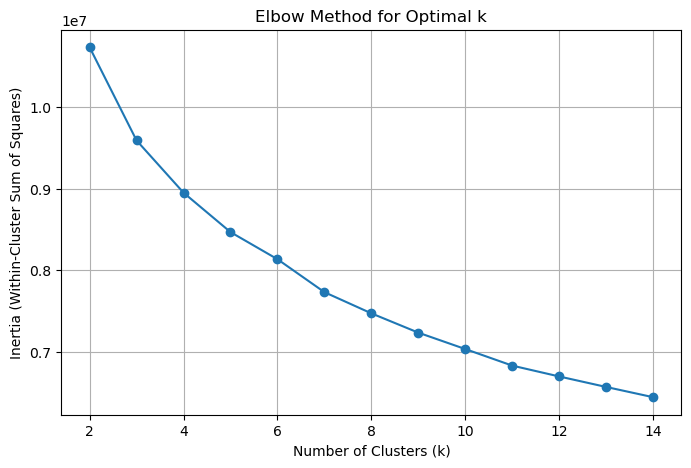

In [101]:
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

# ---------Range of k values to test
k_values = range(2, 15)

inertia = []

for k in k_values:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(df_ecom_data_clean)
    inertia.append(kmeans.inertia_)

# Plot the elbow curve
plt.figure(figsize=(8, 5))
plt.plot(k_values, inertia, marker='o')
plt.title("Elbow Method for Optimal k")
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia (Within-Cluster Sum of Squares)")
plt.grid(True)
plt.show()


**Silhouette score**

In [ ]:
from sklearn.metrics import silhouette_score

for k in range(6, 12):
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = kmeans.fit_predict(df_ecom_data_clean)
    print(f"k={k}, silhouette={silhouette_score(df_ecom_data_clean, labels):.4f}")


This silhouette_score code is taking too long, so tried multiple options and got a suggestion for using MiniBatchKmeans.

In [103]:
from sklearn.cluster import MiniBatchKMeans
from sklearn.metrics import silhouette_score


# ---- Take a sample for silhouette score (e.g., 100k rows)
sample = df_ecom_data_clean.sample(n=min(100000, len(df_ecom_data_clean)), random_state=42)

for k in range(6, 12):
    kmeans = MiniBatchKMeans(n_clusters=k, random_state=42, batch_size=1024)
    labels = kmeans.fit_predict(df_ecom_data_clean)
    
    # Compute silhouette on the sample only
    sil = silhouette_score(sample, kmeans.predict(sample))
    print(f"k={k}, silhouette={sil:.4f}")


k=6, silhouette=0.0970
k=7, silhouette=0.0949
k=8, silhouette=0.0887
k=9, silhouette=0.0934
k=10, silhouette=0.0948
k=11, silhouette=0.0918


Performing a hierarchical clustering, visualising the dendrogram and dtermine the optimal number of clusters (k)

In [ ]:

# Sample 10,000 rows for hierarchical clustering
sample_idx = np.random.choice(len(df_ecom_data_clean), size=10000, replace=False)
df_ecom_data_clean_sample = df_ecom_data_clean.iloc[sample_idx]


In [109]:
df_ecom_data_clean.dtypes

Total Revenue                                            float64
Profit                                                   float64
Quantity                                                 float64
Unit Cost                                                float64
Discount                                                 float64
Days to Delivery                                         float64
Loyalty Num                                              float64
Recency                                                  float64
Frequency                                                float64
Monetary                                                 float64
CLV                                                      float64
Avg_Unit_Cost                                            float64
Customer_Age                                             float64
Customer_Type_Orion  Club members high activity             bool
Customer_Type_Orion  Club members medium activity           bool
Customer_Type_Orion Club 

*Selecting 6 Clusters as per the the scores*

**Customer ID and Clusters, plotting Box Plots wrt eatures identified by business**

In [122]:
# Fit the model and get cluster labels
kmeans = KMeans(n_clusters=6, random_state=42, n_init=10)
labels = kmeans.fit_predict(df_ecom_data_clean)

# Create a DataFrame showing each Customer_ID and its cluster
cluster_df = pd.DataFrame({
    "Customer ID": df_cluster_raw["Customer ID"],
    "Cluster": labels
})

cluster_df.head()

,Customer ID,Cluster
0,8818,0
1,47793,0
2,47793,0
3,71727,4
4,74503,1


In [125]:
import seaborn as sns
import matplotlib.pyplot as plt

df_merged = df_cluster_raw.merge(cluster_df[["Customer ID", "Cluster"]], 
                            on="Customer ID", 
                            how="left")

df_merged.head(2)


,Quantity,City,Continent,Postal_Code,State_Province,Order_Date,Delivery_Date,Total Revenue,Unit Cost,Discount,...,Days to Delivery,Loyalty Num,Customer ID,Customer_Age,Recency,Frequency,Monetary,CLV,Avg_Unit_Cost,Cluster
0,3,Leinster,Oceania,6437,Western Australia,2012-01-01,2012-01-07,28.5,9.1,0,...,6,99,8818,47,1825,31,3732.7,3732.7,60.206452,0
1,3,Leinster,Oceania,6437,Western Australia,2012-01-01,2012-01-07,28.5,9.1,0,...,6,99,8818,47,1825,31,3732.7,3732.7,60.206452,0


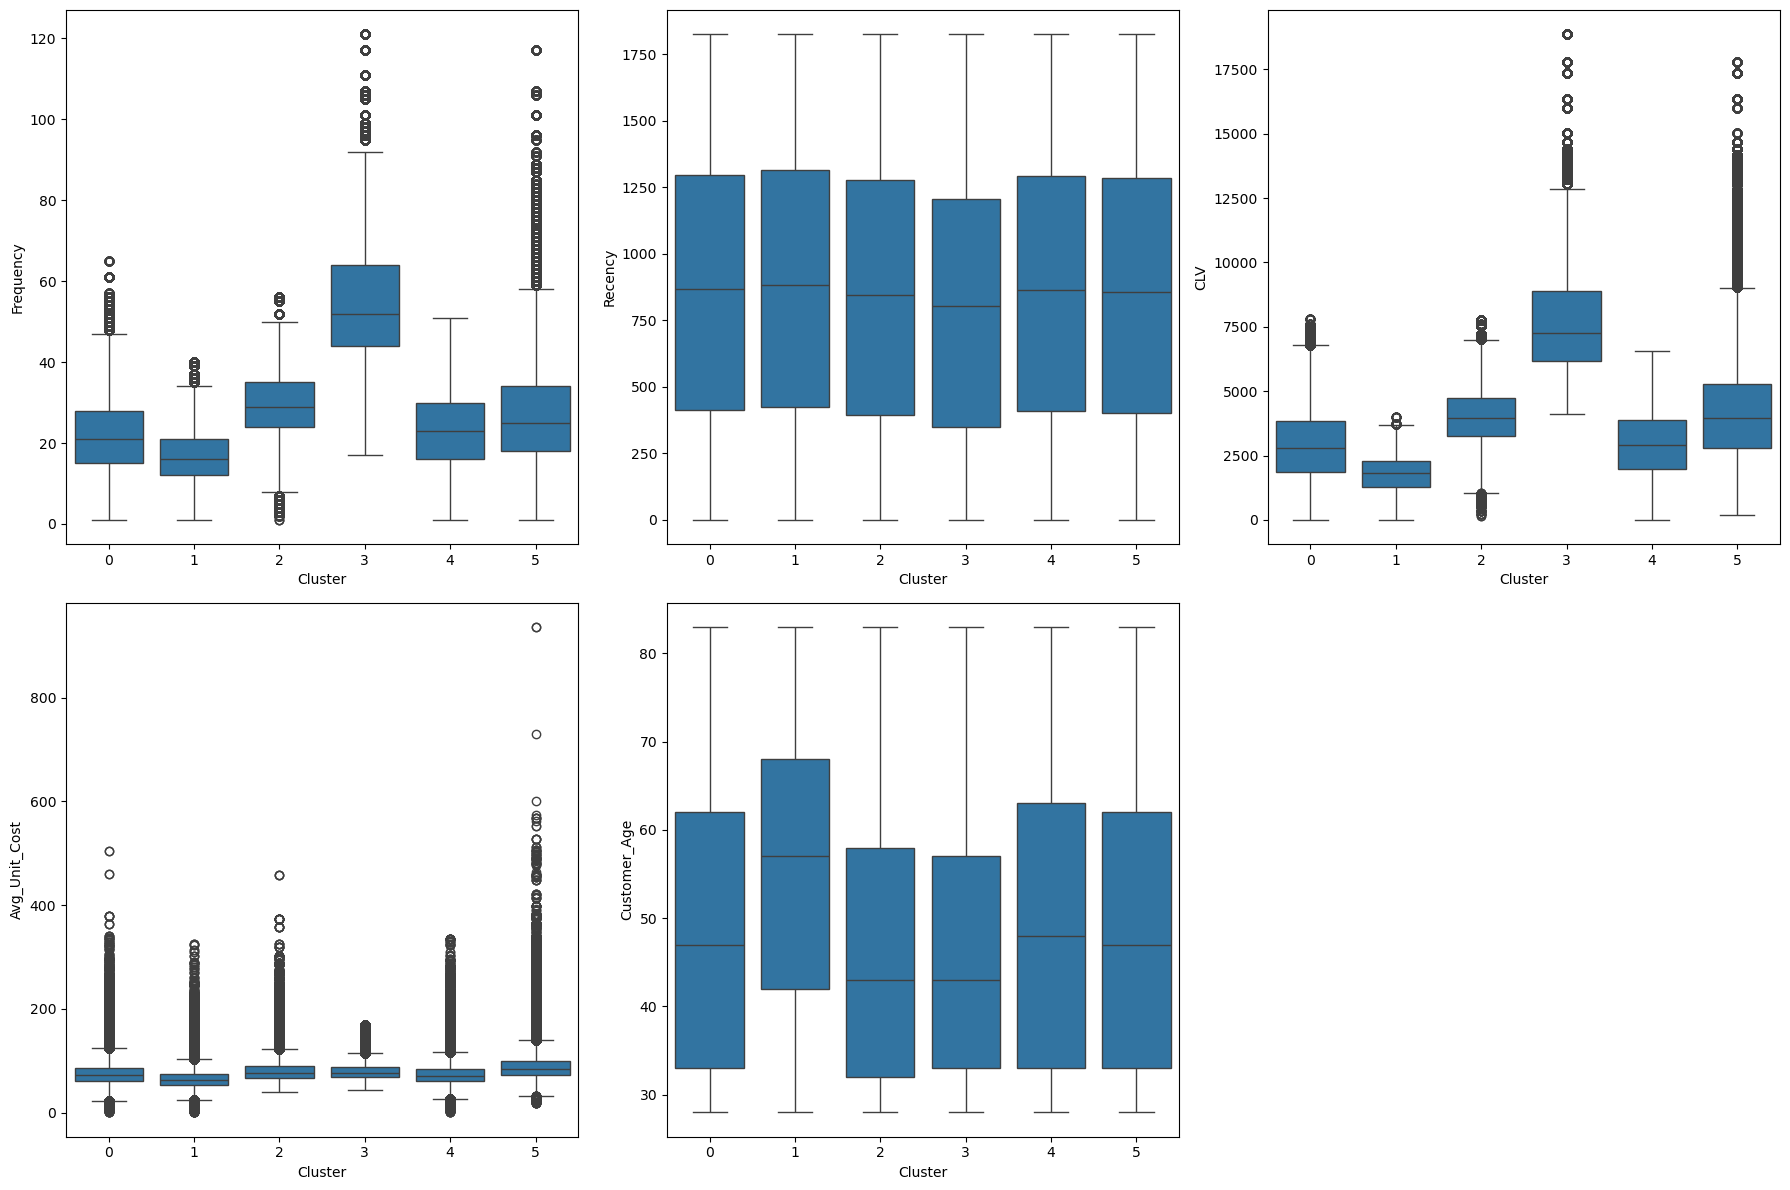

In [127]:
features = [
    "Frequency",
    "Recency",
    "CLV",
    "Avg_Unit_Cost",
    "Customer_Age"
]

plt.figure(figsize=(18, 12))

for i, col in enumerate(features, 1):
    plt.subplot(2, 3, i)
    sns.boxplot(
    data=df_merged,
    x="Cluster",
    y=col
)


plt.tight_layout()
plt.show()

**Creating a 2D visualisation to display the clusters with different colours. Using PCA visuals**

In [115]:
# Run PCA (2 components for visualization)
from sklearn.decomposition import PCA

pca = PCA(n_components=2, random_state=42)
pca_components = pca.fit_transform(df_ecom_data_clean)

# Fit K Means and get labels

kmeans_pca = KMeans(n_clusters=6, random_state=42, n_init=10)
labels_pca = kmeans_pca.fit_predict(df_ecom_data_clean)



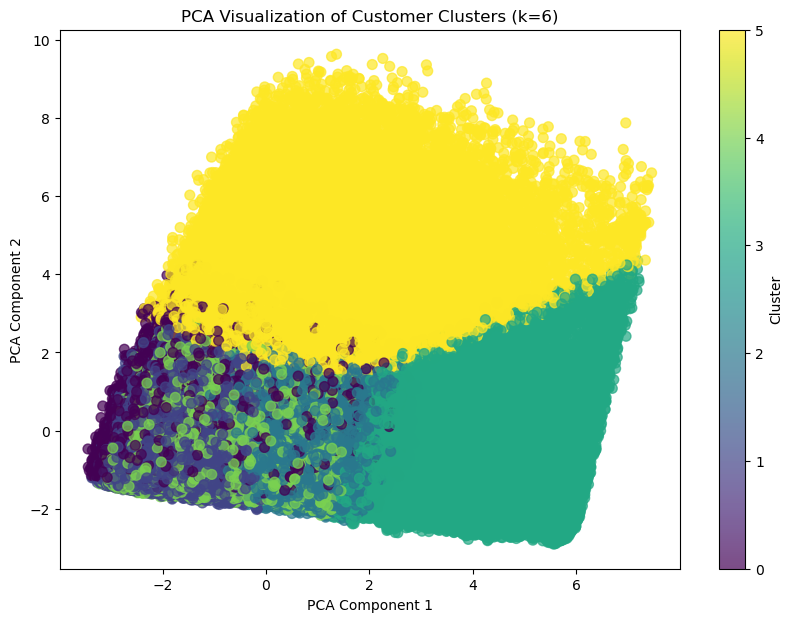

In [116]:
plt.figure(figsize=(10, 7))
plt.scatter(
    pca_components[:, 0],
    pca_components[:, 1],
    c=labels_pca,
    cmap='viridis',
    s=50,
    alpha=0.7
)

plt.xlabel("PCA Component 1")
plt.ylabel("PCA Component 2")
plt.title("PCA Visualization of Customer Clusters (k=6)")
plt.colorbar(label="Cluster")
plt.show()
